In [1]:
import scanpy as sc
from io_utils import save_checkpoint

In [2]:
def run_pca(
    adata: sc.AnnData,
    n_comps: int = 50,
    svd_solver: str = "arpack",
    random_state: int = 0
) -> sc.AnnData:
    """
    Run Principal Component Analysis (PCA) on the current expression matrix, to capture the major sources of variation.
    -----------
    Parameters
    -----------
        adata: AnnData object. 'adata.X' should contain the scaled expression matrix.
        n_comps: Number of principal components to compute.
        svd_solver: SVD solver used by Scanpy/Scikit-learn PCA.
        random_state: Random seed for reproducibility where relevant.
    --------
    Returns
    --------
        adata: AnnData object, updated with:
            - adata.obsm["X_pca"]
            - adata.varm["PCs"]
            - adata.uns["pca"]
    """
    sc.tl.pca(
        adata,
        n_comps = n_comps,
        svd_solver = svd_solver,
        random_state = random_state,
    )

    print(
        f"PCA complete.\n"
        f"Number of PCs computed: {n_comps}\n"
        f"PCA embedding stored in: adata.obsm['X_pca']"
    )

    return adata

In [4]:
def build_neighbor_graph(
    adata: sc.AnnData,
    n_neighbors: int = 15,
    n_pcs: int = 30,
    metric: str = "euclidean",
) -> sc.AnnData:
    """
    Build a k-nearest neighbor graph using PCA coordinates.
    This graph captures cell-cell similarity and is used downstream for UMAP embedding and Leiden clustering.
    -----------
    Parameters
    -----------
        adata: AnnData object. Must contain adata.obsm["X_pca"].
        n_neighbors: Number of neighbors for the kNN graph.
        n_pcs: Number of principal components to use from adata.obsm["X_pca"].
        metric: Distance metric used to compute nearest neighbors.
    --------
    Returns
    --------
        adata: AnnData object, updated with:
            - adata.obsp["distances"]
            - adata.obsp["connectivities"]
            - adata.uns["neighbors"]
    """

    if "X_pca" not in adata.obsm:
        raise KeyError(
            "'X_pca' not found in adata.obsm. "
            "Please run run_pca() first."
        )
    
    sc.pp.neighbors(
        adata,
        n_neighbors = n_neighbors,
        n_pcs = n_pcs,
        metric = metric
    )

    print(
        f"Neighbour graph complete.\n"
        f"n_neighbors used: {n_neighbors}\n"
        f"n_pcs used: {n_pcs}\n"
        f"Graph stored in: adata.obsp['distances'], adata.obsp['connectivities']"
    )

    return adata

In [6]:
def run_umap(
    adata: sc.AnnData,
    min_dist: float = 0.5,
    spread: float = 1.0,
    random_state: int = 0
) -> sc.AnnData:
    """
    Run UMAP embedding for visualisation.
    UMAP projects the neighbor graph into a low-dimensional space, usually 2D, so that cells with similar transcriptional profiles appear close together.
    -----------
    Parameters
    -----------
        adata: AnnData object. Must contain a neighbor graph, typically from build_neighbor_graph().
        min_dist: Controls how tightly UMAP packs points together.
        spread: Controls the overall scale of the UMAP embedding.
        random_state: Random seed for reproducibility.
    --------
    Returns
    --------
        adata: AnnData object, updated with adata.obsm["X_umap"].
    """
    if "neighbors" not in adata.uns:
        raise KeyError(
            "'neighbors' not found in adata.uns. "
            "Please run build_neighbor_graph() first."
        )
    
    sc.tl.umap(
        adata,
        min_dist = min_dist,
        spread = spread,
        random_state = random_state
    )

    print(
        f"UMAP complete.\n"
        f"UMAP coordinates stored in: adata.obsm['X_umap']"
    )

    return adata

Below is the C9ALS sample going through the pipeline.

In [3]:
adata_dir = "../data/processed"
adata_als_scaled = sc.read_h5ad(f"{adata_dir}/c9ALS_GSM5292146_scaled.h5ad")
adata_als_scaled = run_pca(adata_als_scaled)

PCA complete.
Number of PCs computed: 50
PCA embedding stored in: adata.obsm['X_pca']


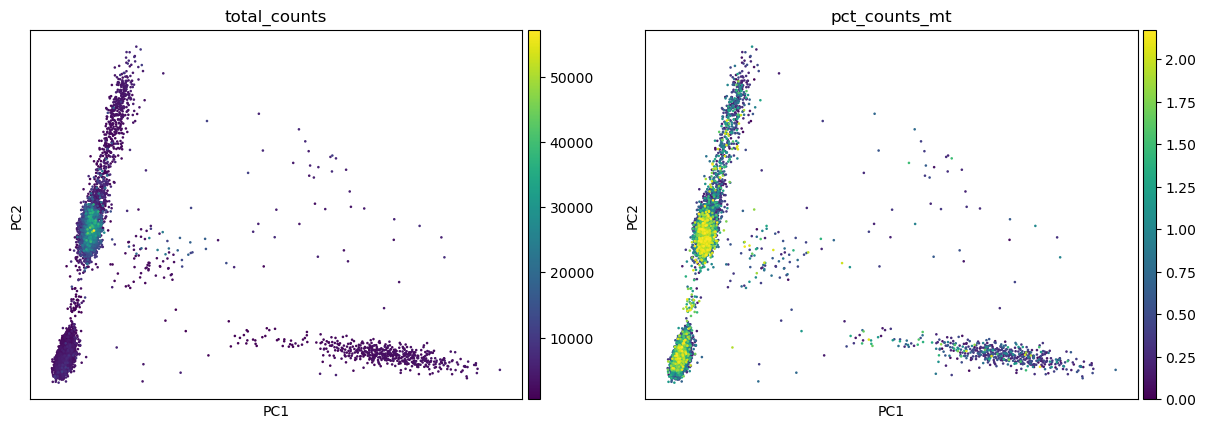

In [9]:
sc.pl.pca(
    adata_als_scaled,
    color = ["total_counts", "pct_counts_mt"],
    components = "1, 2"
)

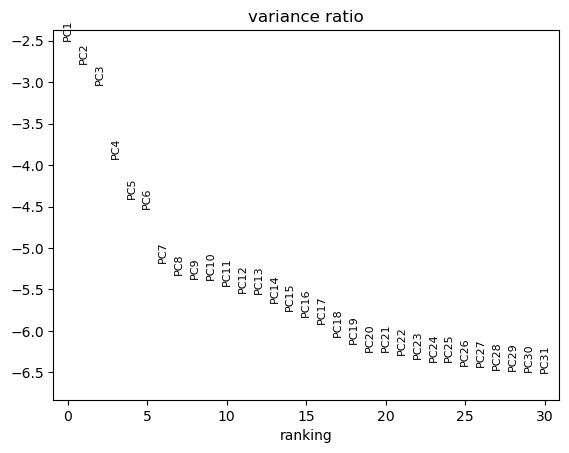

In [10]:
sc.pl.pca_variance_ratio(adata_als_scaled, log=True)

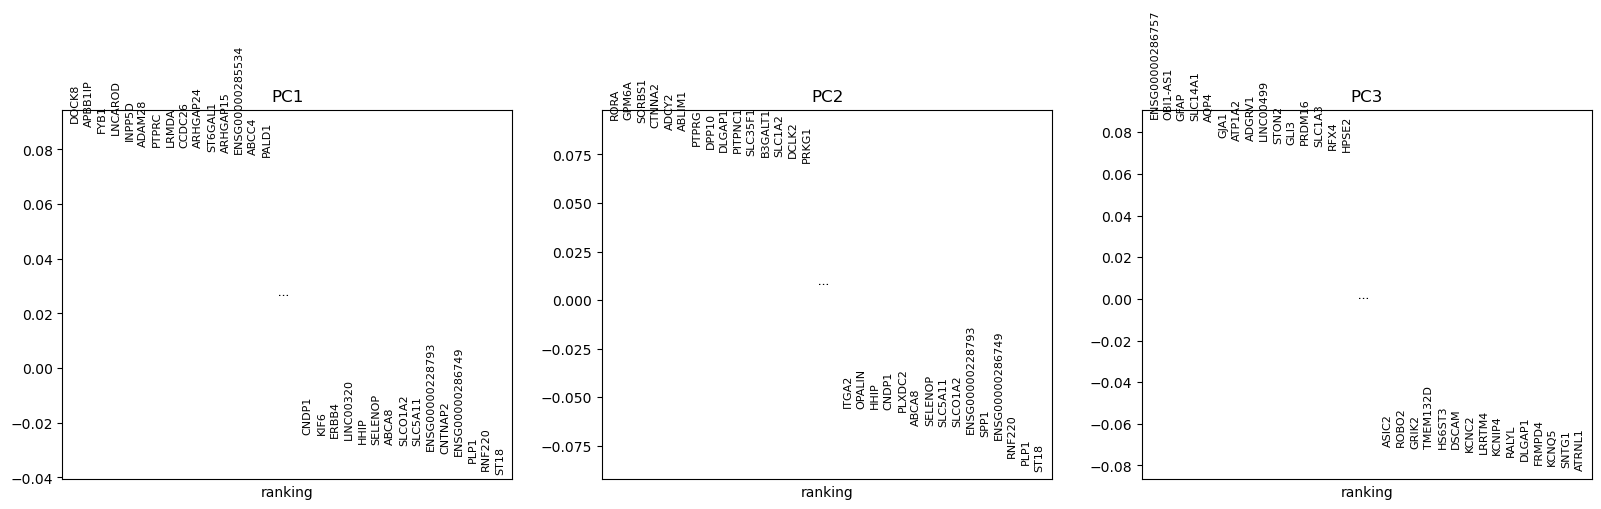

In [11]:
sc.pl.pca_loadings(adata_als_scaled, components = [1, 2, 3], n_points=30)

In [5]:
adata_als_scaled = build_neighbor_graph(adata_als_scaled)

/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Neighbour graph complete.
n_neighbors used: 15
n_pcs used: 30
Graph stored in: adata.obsp['distances'], adata.obsp['connectivities']


In [7]:
adata_als_scaled = run_umap(adata_als_scaled)

UMAP complete.
UMAP coordinates stored in: adata.obsm['X_umap']


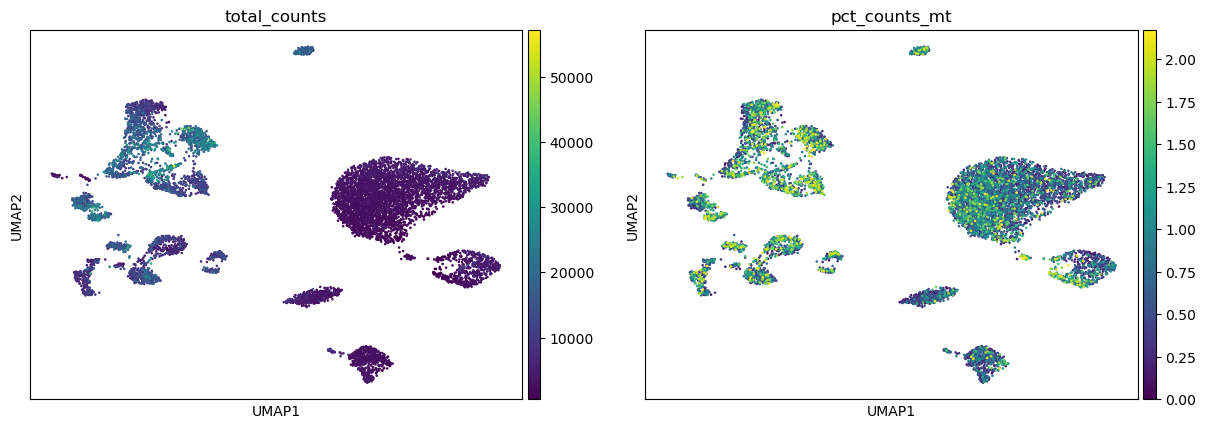

In [13]:
sc.pl.umap(adata_als_scaled, color = ["total_counts", "pct_counts_mt"],)

In [14]:
save_checkpoint(adata_als_scaled,
                "../data/processed", 
                "dimensionality_reduced")

Checkpoint saved: ../data/processed/c9ALS_GSM5292146_dimensionality_reduced.h5ad


PosixPath('../data/processed/c9ALS_GSM5292146_dimensionality_reduced.h5ad')